In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%matplotlib inline
from scipy import stats

# Data 102 Fall 2026 Lecture 12 Demo

## Case Study II: Bayesian Hierarchical Model for Kidney Cancer

## Data Exploration

We'll focus on the following columns in the kidney cancer dataset:
* `state`: the US state
* `Location`: the county and state as a string
* `fips`, which provides the [FIPS code]() for each county: this is a standard identifier that can often be used to join datasets with county-level information.
* `dc` and `dc.2`: the number of kidney cancer deaths between 1980-1984 and 1985-1989, respectively
* `pop` and `pop.2`: the population between 1980-1984 and 1985-1989, respectively

In [3]:
kc_full = pd.read_csv('kidney_cancer_1980.csv', skiprows=4)
# There are many other interesting columns, but we'll focus on these:
kc = kc_full.loc[:, ['state', 'Location', 'dc', 'dc.2', 'pop', 'pop.2']]
kc.head()

,state,Location,dc,dc.2,pop,pop.2
0,ALABAMA,"Autauga County, Alabama",2,1,61921,64915
1,ALABAMA,"Baldwin County, Alabama",7,15,170945,195253
2,ALABAMA,"Barbour County, Alabama",0,1,33316,33987
3,ALABAMA,"Bibb County, Alabama",0,1,30152,31175
4,ALABAMA,"Blount County, Alabama",3,5,88342,91547


In [ ]:
np.isf

In [9]:
kc['rate_nopool'].max()

0.0004520795660036166

In [8]:
kc.loc[~np.isfinite(kc['rate_nopool']), 'rate_nopool']

Series([], Name: rate_nopool, dtype: float64)

/Users/ramesh/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='rate_nopool', ylabel='Count'>

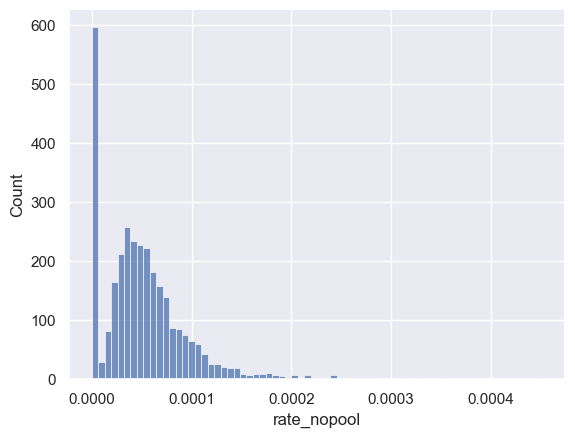

In [4]:
kc['rate_nopool'] = kc['dc'] / kc['pop']
sns.histplot(kc, x='rate_nopool')

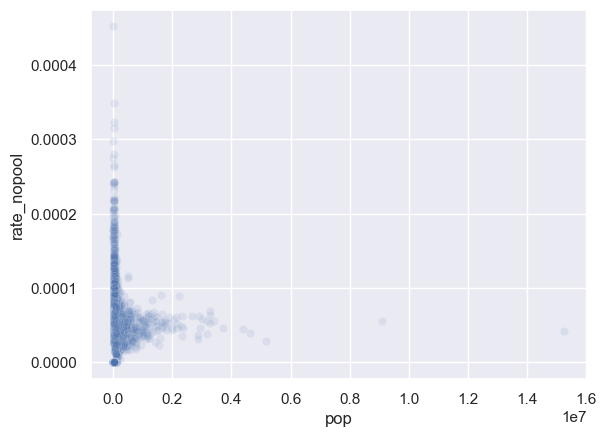

In [10]:
sns.scatterplot(kc, x='pop', y='rate_nopool', alpha=0.1);

In [11]:
# Complete pooling
total_pop = kc['pop'].sum()
total_dc = kc['dc'].sum()
overall_rate = total_dc / total_pop
overall_rate

4.856485743364176e-05

### Hierarchical model

Prior and likelihood:
$$
\begin{align*}
\theta_i &\sim \mathrm{Beta}(a, b), & i \in \{1, 2, \ldots\} \\
y_i &\sim \mathrm{Binomial}(\theta_i, n_i), & i \in \{1, 2, \ldots\}
\end{align*}
$$

Posterior
$$
\theta_i | y_i \sim \mathrm{Beta}(a + y_i, b + n_i - y_i)
$$



# Sampling

## Simple example: sampling for a known distribution

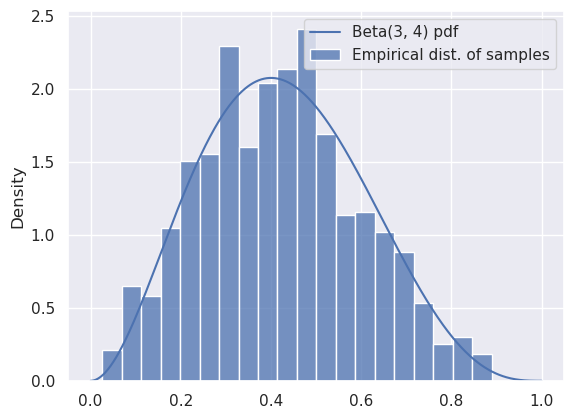

In [28]:

from scipy import stats

my_distribution = stats.beta(3, 4)

# Compute the exact PDF:
t = np.linspace(0, 1, 500)
pdf = my_distribution.pdf(t)

# Draw 1000 samples, and look at the empirical distribution of those samples:
samples = my_distribution.rvs(1000)
f, ax = plt.subplots(1, 1)

sns.histplot(x=samples, stat='density', bins=20, label='Empirical dist. of samples')
ax.plot(t, pdf, label='Beta(3, 4) pdf')
ax.legend()

## Sampling with PyMC

In [12]:
import pymc as pm
import arviz as az


In [13]:
reviews_a = np.array([1, 1, 1])
reviews_b = np.append(np.ones(19), np.zeros(1))

In [14]:


# Parameters of the prior
a = 1
b = 5

with pm.Model() as model:
    # Define a Beta-distributed random variable called theta
    theta = pm.Beta('theta', alpha=a, beta=b)
    
    # Defines a Bernoulli RV called x. Since x is observed, we
    # pass in the observed= argument to provide our data
    x = pm.Bernoulli('x', p=theta, observed=reviews_b)
    
    # This line asks PyMC3 to approximate the posterior.
    # Don't worry too much about how it works for now.
    trace = pm.sample(2000, chains=2, tune=200, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [theta]


Output()

Sampling 2 chains for 200 tune and 2_000 draw iterations (400 + 4_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [15]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [16]:
trace.posterior

<xarray.Dataset> Size: 48kB
Dimensions:  (chain: 2, draw: 2000)
Coordinates:
  * chain    (chain) int64 16B 0 1
  * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
Data variables:
    theta    (chain, draw) float64 32kB 0.8594 0.8352 0.8411 ... 0.6199 0.7036
Attributes:
    created_at:                 2025-09-18T16:29:06.557442+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.17.0
    sampling_time:              0.5532248020172119
    tuning_steps:               200

In [17]:
samples = trace.posterior['theta'].values.flatten()

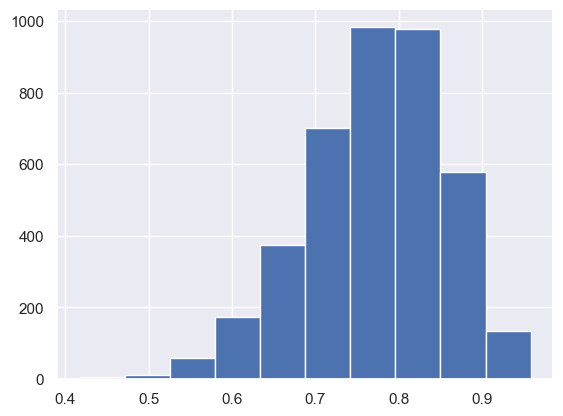

In [18]:
plt.hist(samples);

### Kidney cancer death model

In [19]:


# Parameters of the prior
a = 9
b = 195581
num_counties = kc.shape[0]

with pm.Model() as model:
    theta = pm.Beta('theta', alpha=a, beta=b, shape=num_counties)
    y = pm.Binomial('y', p=theta, n=kc['pop'], observed=kc['dc'])
    
    # This line asks PyMC3 to approximate the posterior.
    # Don't worry too much about how it works for now.
    trace_hier = pm.sample(2000, chains=2, tune=200, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [theta]


Output()

Sampling 2 chains for 200 tune and 2_000 draw iterations (400 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [20]:
thetas = trace_hier.posterior['theta'].values
thetas.shape

(2, 2000, 3110)

In [21]:
thetas = thetas.reshape(-1, 3110)
thetas

array([[3.45249022e-05, 4.30722816e-05, 2.58457089e-05, ...,
        4.10845672e-05, 4.12877028e-05, 7.89977066e-05],
       [2.69373041e-05, 4.82527400e-05, 3.03748630e-05, ...,
        3.71006292e-05, 4.33223011e-05, 4.07368472e-05],
       [2.80494291e-05, 5.72907508e-05, 2.07217531e-05, ...,
        3.06563744e-05, 7.16879063e-05, 4.37943349e-05],
       ...,
       [4.34830920e-05, 3.53579465e-05, 4.24822047e-05, ...,
        3.84094477e-05, 3.51609571e-05, 7.33028066e-05],
       [3.43465412e-05, 5.34471599e-05, 2.95099727e-05, ...,
        4.42177323e-05, 3.61858772e-05, 2.76022970e-05],
       [4.49201736e-05, 3.35616039e-05, 5.52464329e-05, ...,
        3.66514333e-05, 5.71141696e-05, 7.48006866e-05]])

In [22]:
thetas.shape

(4000, 3110)